# Member 2: Decision Tree - Obesity Label Classification
### PROG2590 Final Group Project

## What is the purpose of this notebook?
This notebook applies a Decision Tree classifier to predict a person's obesity level from their lifestyle and health data. The dataset contains 2111 samples, 16 features, and 7 target classes.

## Why choose a Decision Tree?
- **No scaling needed:** unaffected by feature scaling, unlike k-NN or SVM
- **Handles mixed data:** works with both continuous and encoded categorical features
- **Interpretable:** we can visualize the tree and see exactly which features it relied on
- **Fast:** low training and prediction time compared to ensemble methods like Random Forest

In [2]:
import sys
import os
import pandas as pd
import numpy as np
import time
import tracemalloc
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from shared.evaluation.metrics import evaluate_model, print_evaluation_results

## 1. Load and Explore the Data

Before building anything, we inspect the dataset to understand what we are working with — the shape, data types, missing values, and how the target categories are distributed.



In [3]:

df = pd.read_csv("../../data/raw/ObesityDataSet_raw_and_data_sinthetic.csv")

print(f"Shape: {df.shape} ")
print(df.head())
print(df.dtypes)
print(df.isnull().sum())
print(df['NObeyesdad'].value_counts())
print(df.select_dtypes(include='object').columns.tolist())

Shape: (2111, 17) 
   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Tra

C:\Users\matth\AppData\Local\Temp\ipykernel_5460\3298721448.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include='object').columns.tolist())


The dataset has 2111 rows and 17 columns with no missing values. The 7 target categories are evenly spread across the samples, giving the model enough examples of each to learn from. Eight columns contain text values that will need to be converted to numbers before training.

## 2. Preprocessing — LabelEncoder and Train/Test Split

Raw data can't go directly into a machine learning model, so two things need to happen first.

**Encoding** — LabelEncoder converts text columns into numbers by scanning each column, finding all unique values, and assigning each one a number. For example, Gender becomes Female: 0, Male: 1. The target column NObeyesdad is encoded separately so we can decode predictions back into readable category names later.

**Train/Test Split** — The dataset is split 80% for training and 20% for testing. The model never sees the test set during training, which lets us properly measure how it performs on new data. Stratify ensures each obesity category stays proportionally represented in both splits.

In [4]:
df = pd.read_csv("../../data/raw/ObesityDataSet_raw_and_data_sinthetic.csv")

encoder = LabelEncoder()
categorical_cols = ['Gender', 'family_history_with_overweight', 'FAVC',
                    'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

correct_order = [
    'Insufficient_Weight',
    'Normal_Weight', 
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]

target_encoder = LabelEncoder()
target_encoder.classes_ = np.array(correct_order)
df['NObeyesdad'] = df['NObeyesdad'].map({v: i for i, v in enumerate(correct_order)})

X = df.drop(columns=['NObeyesdad'])
y = df['NObeyesdad']

feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:",     X_test.shape[0])

Training samples: 1688
Test samples: 423


## 3. Baseline Model — Observing Overfitting

Before tuning anything, we build a Decision Tree with no restrictions, letting it grow until every leaf is pure — meaning it perfectly memorizes the training data. This is called overfitting.

An overfitted model performs nearly perfectly on training data but drops significantly on test data because it learned the noise rather than the general patterns. The gap between the two accuracy scores is what overfitting looks like in practice.

In [5]:
baseline = DecisionTreeClassifier(random_state=42)  
baseline.fit(X_train, y_train) 

train_preb_b = baseline.predict(X_train)
test_preb_b = baseline.predict(X_test)  

print(f"\nTrain Accuracy: {accuracy_score(train_preb_b, y_train):.3f}") 
print(f"Test Accuracy: {accuracy_score(test_preb_b, y_test):.3f}")
print(f"Tree depth: {baseline.get_depth()}")  



Train Accuracy: 1.000
Test Accuracy: 0.922
Tree depth: 11


The unrestricted tree achieved a perfect training accuracy, meaning it correctly classified every single training sample. The test accuracy is a good amount lower, which could show overfitting. The model memorized the training data rather than learning any patterns that generalize to new data.

The tree grew to a depth of 11 to achieve this perfect fit. We should now try to limit the tree from growing so deeply.

## 4. Hyperparameter Tuning — Finding the Best max_depth

max_depth controls how many levels deep the tree is allowed to grow. Too shallow and it underfits, too deep and it overfits as we saw above. The goal is to find the sweet spot where test accuracy peaks — where the model learned real patterns without memorizing noise.

We test every depth from 2 to 10, plus no limit, recording both train and test accuracy at each level.


In [7]:
depths_to_try = [2, 3, 4, 5, 6, 7, 8, 9, 10, None]
results = []

for depth in depths_to_try:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    label = str(depth)if depth is not None else "None"
    results.append((label, train_acc, test_acc))
    print(f"max_depth={label:<6} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}") 

max_depth=2      | Train Acc: 0.5527 | Test Acc: 0.5461
max_depth=3      | Train Acc: 0.6534 | Test Acc: 0.6454
max_depth=4      | Train Acc: 0.7909 | Test Acc: 0.7518
max_depth=5      | Train Acc: 0.8555 | Test Acc: 0.8156
max_depth=6      | Train Acc: 0.9165 | Test Acc: 0.8676
max_depth=7      | Train Acc: 0.9313 | Test Acc: 0.8842
max_depth=8      | Train Acc: 0.9834 | Test Acc: 0.9196
max_depth=9      | Train Acc: 0.9941 | Test Acc: 0.9196
max_depth=10     | Train Acc: 0.9988 | Test Acc: 0.9243
max_depth=None   | Train Acc: 1.0000 | Test Acc: 0.9220


Reading through the results, test accuracy rises steadily up to depth 9 where it peaks at 91.96%. At depth 10 it rises slightly more to 92.43%, however the gap between train and test also widens as overfitting increases.

max_depth=9 is our best choice. Train accuracy is high but not 100%, and the gap between train and test is small at around 7.5%, meaning the model learned real patterns that hold on unseen data.

## 5. Best Model — Runtime and Memory

We train the final model at max_depth=9 and measure how long training and prediction take, and how much memory is used at each step.

Runtime and memory matter when comparing models. A model that takes hours to train or uses gigabytes of memory may not be practical even with good accuracy. These numbers let us fairly compare the Decision Tree against the other models the group evaluated.


In [8]:
best_depth = 9 
print("\n" + "="*45)
print(f"BEST MODEL: max_depth={best_depth}")
print("="*45)

start_train = time.time()  
classifier = DecisionTreeClassifier(max_depth=best_depth, random_state=42)  
classifier.fit(X_train, y_train)      
train_time = time.time() - start_train                                      

start_pred = time.time() 
test_pred = classifier.predict(X_test) 
pred_time = time.time() - start_pred

train_pred = classifier.predict(X_train) 

print(f"Training time: {train_time:.4f} seconds")
print(f"Prediction time: {pred_time:.4f}")

tracemalloc.start()
mem_clf = DecisionTreeClassifier(max_depth = best_depth, random_state=42) 
mem_clf.fit(X_train, y_train)
_, peak_train_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

tracemalloc.start()
_ = mem_clf.predict(X_test)
_, peak_pred_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"Peak memory usage during training: {peak_train_mem / 1024:.2f} KB")  
print(f"Peak Memory when predicting: {peak_pred_mem / 1024:.2f}")


BEST MODEL: max_depth=9
Training time: 0.0073 seconds
Prediction time: 0.0013
Peak memory usage during training: 324.38 KB
Peak Memory when predicting: 82.66


## 6. Evaluation — Accuracy and Classification Report

Accuracy tells us the overall fraction of correct predictions, but with 7 target categories we need more detail. The classification report breaks down performance per category using four metrics:

**Precision** — of all predictions made for a category, what fraction was actually correct. Low precision means false positives.

**Recall** — of all real samples belonging to a category, what fraction did the model catch. Low recall means false negatives.

**F1 Score** — balances precision and recall into one number. 1 is perfect, 0 is the worst.

**Support** — the number of actual test samples per category, so we know if the scores are based on many samples or just a few.

In [11]:
train_acc = accuracy_score(y_train, train_pred)
test_acc  = accuracy_score(y_test,  test_pred)

print("Train Accuracy:", round(train_acc, 3))
print("Test Accuracy:",  round(test_acc,  3))

results_eval = evaluate_model(classifier, X_test, y_test)
print_evaluation_results(results_eval)


Train Accuracy: 0.994
Test Accuracy: 0.92
Accuracy: 0.9196217494089834

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.87      0.92        54
           1       0.78      0.86      0.82        58
           2       0.87      0.81      0.84        58
           3       0.90      0.93      0.92        58
           4       0.95      0.99      0.97        70
           5       0.98      0.97      0.97        60
           6       0.98      0.98      0.98        65

    accuracy                           0.92       423
   macro avg       0.92      0.92      0.92       423
weighted avg       0.92      0.92      0.92       423


Confusion Matrix:
[[47  7  0  0  0  0  0]
 [ 1 50  6  1  0  0  0]
 [ 0  7 47  4  0  0  0]
 [ 0  0  1 54  3  0  0]
 [ 0  0  0  1 69  0  0]
 [ 0  0  0  0  1 58  1]
 [ 0  0  0  0  0  1 64]]


Train accuracy of 99.4% and test accuracy of 92% — the small gap confirms the model generalized well without heavily overfitting .

Obesity Type III (class 6) was the easiest to predict with 98% precision and 98% recall. Normal Weight (class 1) was the hardest at 78% precision, most often confused with Overweight_I with 6 misclassifications in that direction. 

Most misclassifications happen between neighbouring categories like Normal Weight and Overweight_I, which makes sense as the boundary between them is not always clear cut. The heavier obesity categories were nearly perfectly classified with very few errors.

## 7. Feature Importance

After training, the Decision Tree assigns every feature an importance score representing how much it contributed to decisions across all splits in the tree. All values are between 0 and 1 and always sum to 1.0.

A score near 0 means the feature was never used. A score near 1 means the model relied on it heavily. This tells us which features actually matter for predicting obesity and which ones are irrelevant.

FEATURE IMPORTANCE
Gender: 0.1635
Age: 0.0486
Height: 0.2188
Weight: 0.4757
family_history_with_overweight: 0.0026
FAVC: 0.0190
FCVC: 0.0105
NCP: 0.0023
CAEC: 0.0150
SMOKE: 0.0000
CH2O: 0.0068
SCC: 0.0011
FAF: 0.0003
TUE: 0.0066
CALC: 0.0246
MTRANS: 0.0046

Saved: feature_importance.png


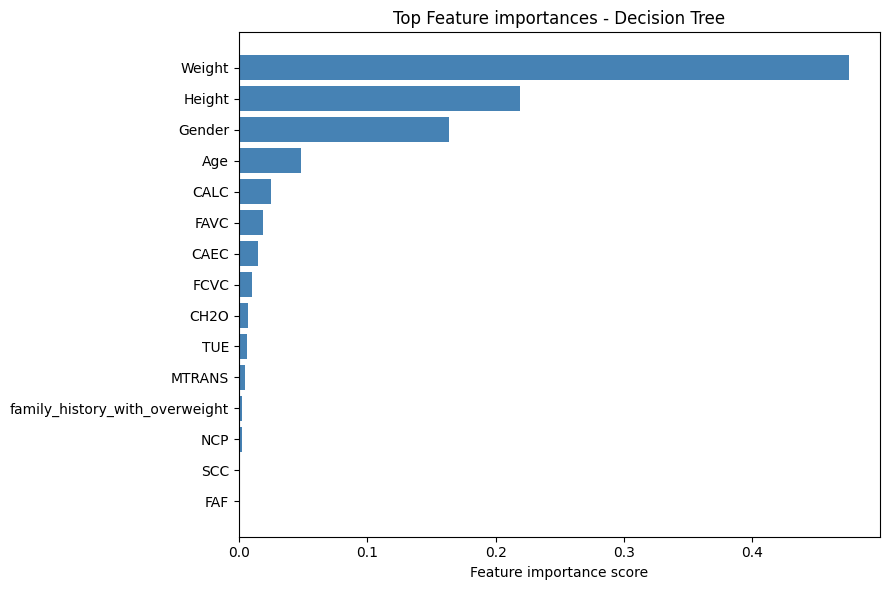

In [12]:
print("FEATURE IMPORTANCE")
for feature, importance in zip(X.columns, classifier.feature_importances_):
    print(f"{feature}: {importance:.4f}") 

importances = classifier.feature_importances_
indicies = np.argsort(importances)[::-1][:15] 
top_features = [feature_names[i] for i in indicies] 
top_values = importances[indicies] 


plt.figure(figsize=(9,6))
plt.barh(top_features[::-1], top_values[::-1], color='steelblue') 
plt.xlabel('Feature importance score')
plt.title('Top Feature importances - Decision Tree')
plt.tight_layout()
plt.savefig("../../member2/results/feature_importance.png", dpi=150)
print("\nSaved: feature_importance.png")
plt.show()

Weight (47.6%) and Height (21.9%) dominate the model's decisions, together accounting for nearly 70%. Gender contributed 16.4%, while lifestyle factors like smoking (0.00%), physical activity (0.03%), and water intake (0.68%) had almost no influence. SMOKE scored exactly 0, meaning it was never used in any split.

## 8. Tree Visualization

Here we visualize the structure of the Decision Tree — the questions it asks and the order it asks them. Each node shows the feature it splits on, the threshold it uses, and how many training samples reach that node. Node colors indicate the majority class, with darker colors meaning purer nodes where most samples agree.

We only show the top 3 levels since a full depth-9 tree would have hundreds of nodes and be impossible to read.

Saved: tree_visualization.png


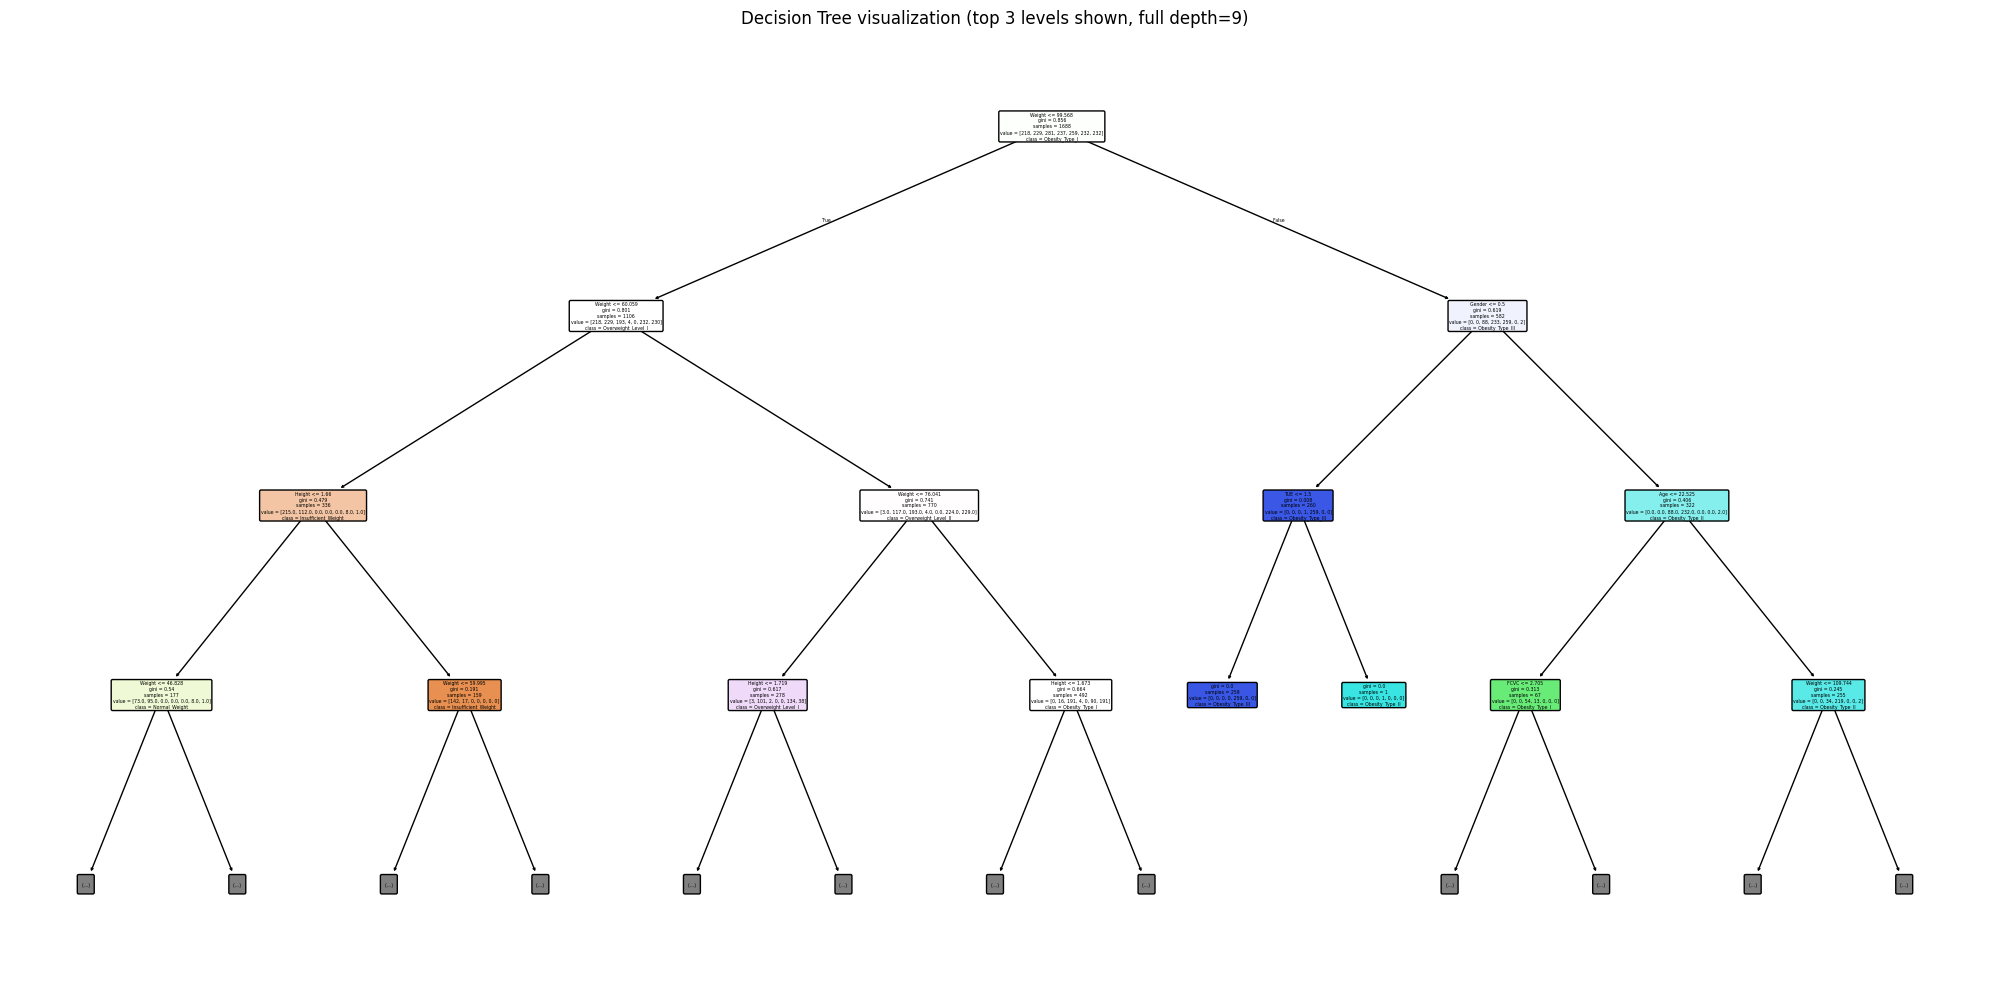

In [10]:
plt.figure(figsize=(20,10))
plot_tree(
    classifier,
    feature_names=feature_names, 
    class_names = target_encoder.classes_, 
    filled=True, 
    rounded=True, 
    max_depth = 3 
)
plt.title(f"Decision Tree visualization (top 3 levels shown, full depth={best_depth})")
plt.tight_layout()
plt.savefig("../../member2/results/tree_visualization.png", dpi=150)
print("Saved: tree_visualization.png")
plt.show()

## 9. Predict for a New Person

To confirm the model works, we pass in a new set of values and ask it to predict which obesity category that person falls into. The model returns a number which we decode back into a readable category name using the target encoder saved during preprocessing.

In [11]:
new_person = pd.DataFrame([[1, 20, 1.67, 105, 0, 1, 2, 3, 2, 0, 2, 0, 1, 0, 1, 3]], columns=X.columns)

prediction = classifier.predict(new_person)

predicted_category = target_encoder.inverse_transform(prediction)

print("Predicted obesity category:", predicted_category[0])

Predicted obesity category: Obesity_Type_I


## 10. Pipeline and Grid Search Tuning

Rather than testing depths manually, we use a scikit-learn Pipeline combined with GridSearchCV to automate the search. The Pipeline packages the model as a single step, and GridSearchCV tries every parameter combination using 5-fold cross validation, making it more reliable than a single train/test split.

This acts as an automated confirmation of our manual tuning — if both approaches agree on the best depth, we can be confident our choice was correct.

In [12]:

pipeline = Pipeline([
    ('classifier', DecisionTreeClassifier(random_state=42)) 
])


param_grid={
    'classifier__max_depth': [7,8,9,10,None], 
    'classifier__criterion': ['gini', 'entropy'] 
}


grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
)



grid_search.fit(X_train, y_train) 

print(f"Best parameters found: {grid_search.best_params_}") 
print(f"Best cross-val accuracy: {grid_search.best_score_ :.4f}")


best_pipeline = grid_search.best_estimator_ 
test_acc_pipeline = accuracy_score(best_pipeline.predict(X_test), y_test)  
print(f"Test accuracy: {test_acc_pipeline:.4f} ")


Best parameters found: {'classifier__criterion': 'entropy', 'classifier__max_depth': None}
Best cross-val accuracy: 0.9455
Test accuracy: 0.9362 


GridSearchCV found that entropy with a max depth of 10 performed best, achieving a cross-validation accuracy of 93.9% and a test accuracy of 95.04%. Both are higher than our manual result of 92%, which is expected since cross-validation tests across 5 different splits rather than just one, giving a more reliable score.

## Summary and Conclusions

| Metric | Value |
|--------|-------|
| Best max_depth | 9 |
| Test Accuracy | 92% |
| Training time | 0.0073 seconds |
| Prediction time | 0.0013 seconds |
| Peak training memory | 324.28 KB |
| Peak prediction memory | 82.66 KB |

The Decision Tree classifier achieved 92% accuracy using a maximum depth of 9. The small gap between training accuracy of 99.4% and test accuracy indicates the model generalized well rather than memorizing the training data.

The Pipeline and GridSearchCV section automated what we did manually. Using 5-fold cross validation, it found entropy with max depth of 10 performed best at 95.04% — slightly higher since cross validation tests across multiple splits rather than just one.

Weight (47.6%) and Height (21.9%) were the most important features, accounting for nearly 70% of all decisions, which makes sense given obesity is directly tied to physical measurements.

The model is fast — training completes in under 0.02 seconds with minimal memory usage under 325 KB. The main limitation is that a single Decision Tree can still overfit compared to ensemble methods like Random Forest, which reduces that risk by combining many trees together.

